In [14]:
import xarray as xr
import matplotlib.pyplot as plt
import os
import numpy as np
import cartopy.crs as ccrs
from matplotlib.colors import BoundaryNorm

In [7]:
hr = xr.open_dataset(
    os.path.join(os.environ['E3SM_ROOT'], 'inputdata', 'lnd', 'clm2', 'surfdata_map', 
                 'surfdata_0.5x0.5_simyr1850_c240308_TOP.nc')
)

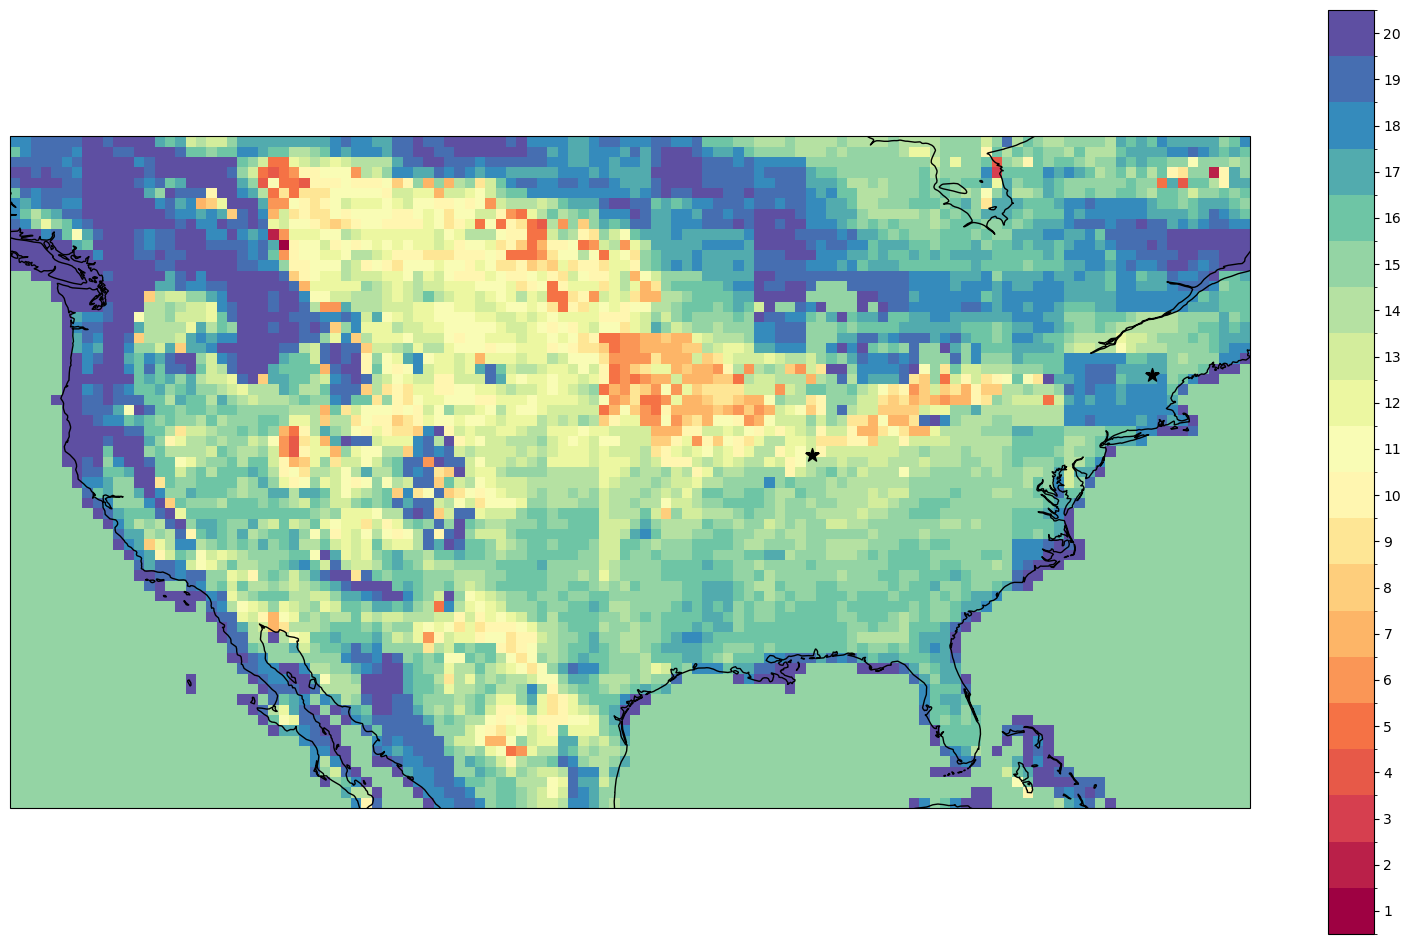

In [35]:
lat = hr['LATIXY'][:, 0].values
lon = hr['LONGXY'][0, :].values

fig, ax = plt.subplots(figsize = (20, 12), subplot_kw={'projection': ccrs.PlateCarree()})

ax.coastlines()
ax.set_extent([-127,-67,23,52])

# Hubbard Brook, UIEF
ax.scatter(-360+288.271175, 43.9556695, marker = '*', s = 100, color = 'k', zorder = 3)
ax.scatter(-360+271.80389, 40.06278, marker = '*', s = 100, color = 'k', zorder = 3)

norm = BoundaryNorm(np.arange(0.5, 21, 1), ncolors = 256)

cf = ax.pcolormesh(lon, lat, hr['SOIL_COLOR'], cmap = 'Spectral', 
                   norm = norm)
plt.colorbar(cf, ax = ax, ticks = np.arange(1, 21))